In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('personality_synthetic_dataset.csv')

In [3]:
df.head()

,personality_type,social_energy,alone_time_preference,talkativeness,deep_reflection,group_comfort,party_liking,listening_skill,empathy,creativity,...,spontaneity,adventurousness,reading_habit,sports_interest,online_social_usage,travel_desire,gadget_usage,work_style_collaborative,decision_speed,stress_handling
0,Extrovert,6.794295,3.854670,8.725446,2.515151,7.097368,8.588762,6.774799,6.430132,6.142968,...,4.853313,8.257134,5.270555,10.000000,9.154296,4.816422,9.191711,8.313590,8.032376,7.176905
1,Ambivert,6.378988,5.731157,7.029529,7.274493,4.111199,3.258248,5.550909,3.958179,6.149457,...,6.067201,6.289347,5.753165,5.334303,4.683781,4.725666,5.956141,5.890619,3.158988,3.423577
2,Ambivert,7.459421,6.322263,3.922269,4.622261,5.343276,7.452152,9.483990,6.127654,7.032017,...,5.524244,9.238784,5.250405,3.153540,5.000338,6.139166,6.033048,5.807500,4.571003,5.647480
3,Extrovert,6.159626,3.097837,6.019093,1.965440,7.837140,10.000000,9.436733,8.949684,8.923875,...,4.327018,8.489791,5.312617,8.379936,7.601946,6.370056,5.410145,6.671781,6.600233,5.870088
4,Introvert,5.568462,6.986722,3.913240,9.926161,1.650483,0.362298,7.470387,6.756837,9.507803,...,5.187689,3.167217,7.060235,2.333388,7.771569,5.534336,5.704598,5.832968,5.813099,3.758084


In [4]:
df.isnull().sum()

,0
personality_type,0
social_energy,0
alone_time_preference,0
talkativeness,0
deep_reflection,0
group_comfort,0
party_liking,0
listening_skill,0
empathy,0
creativity,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   personality_type          20000 non-null  object 
 1   social_energy             20000 non-null  float64
 2   alone_time_preference     20000 non-null  float64
 3   talkativeness             20000 non-null  float64
 4   deep_reflection           20000 non-null  float64
 5   group_comfort             20000 non-null  float64
 6   party_liking              20000 non-null  float64
 7   listening_skill           20000 non-null  float64
 8   empathy                   20000 non-null  float64
 9   creativity                20000 non-null  float64
 10  organization              20000 non-null  float64
 11  leadership                20000 non-null  float64
 12  risk_taking               20000 non-null  float64
 13  public_speaking_comfort   20000 non-null  float64
 14  curios

<Axes: >

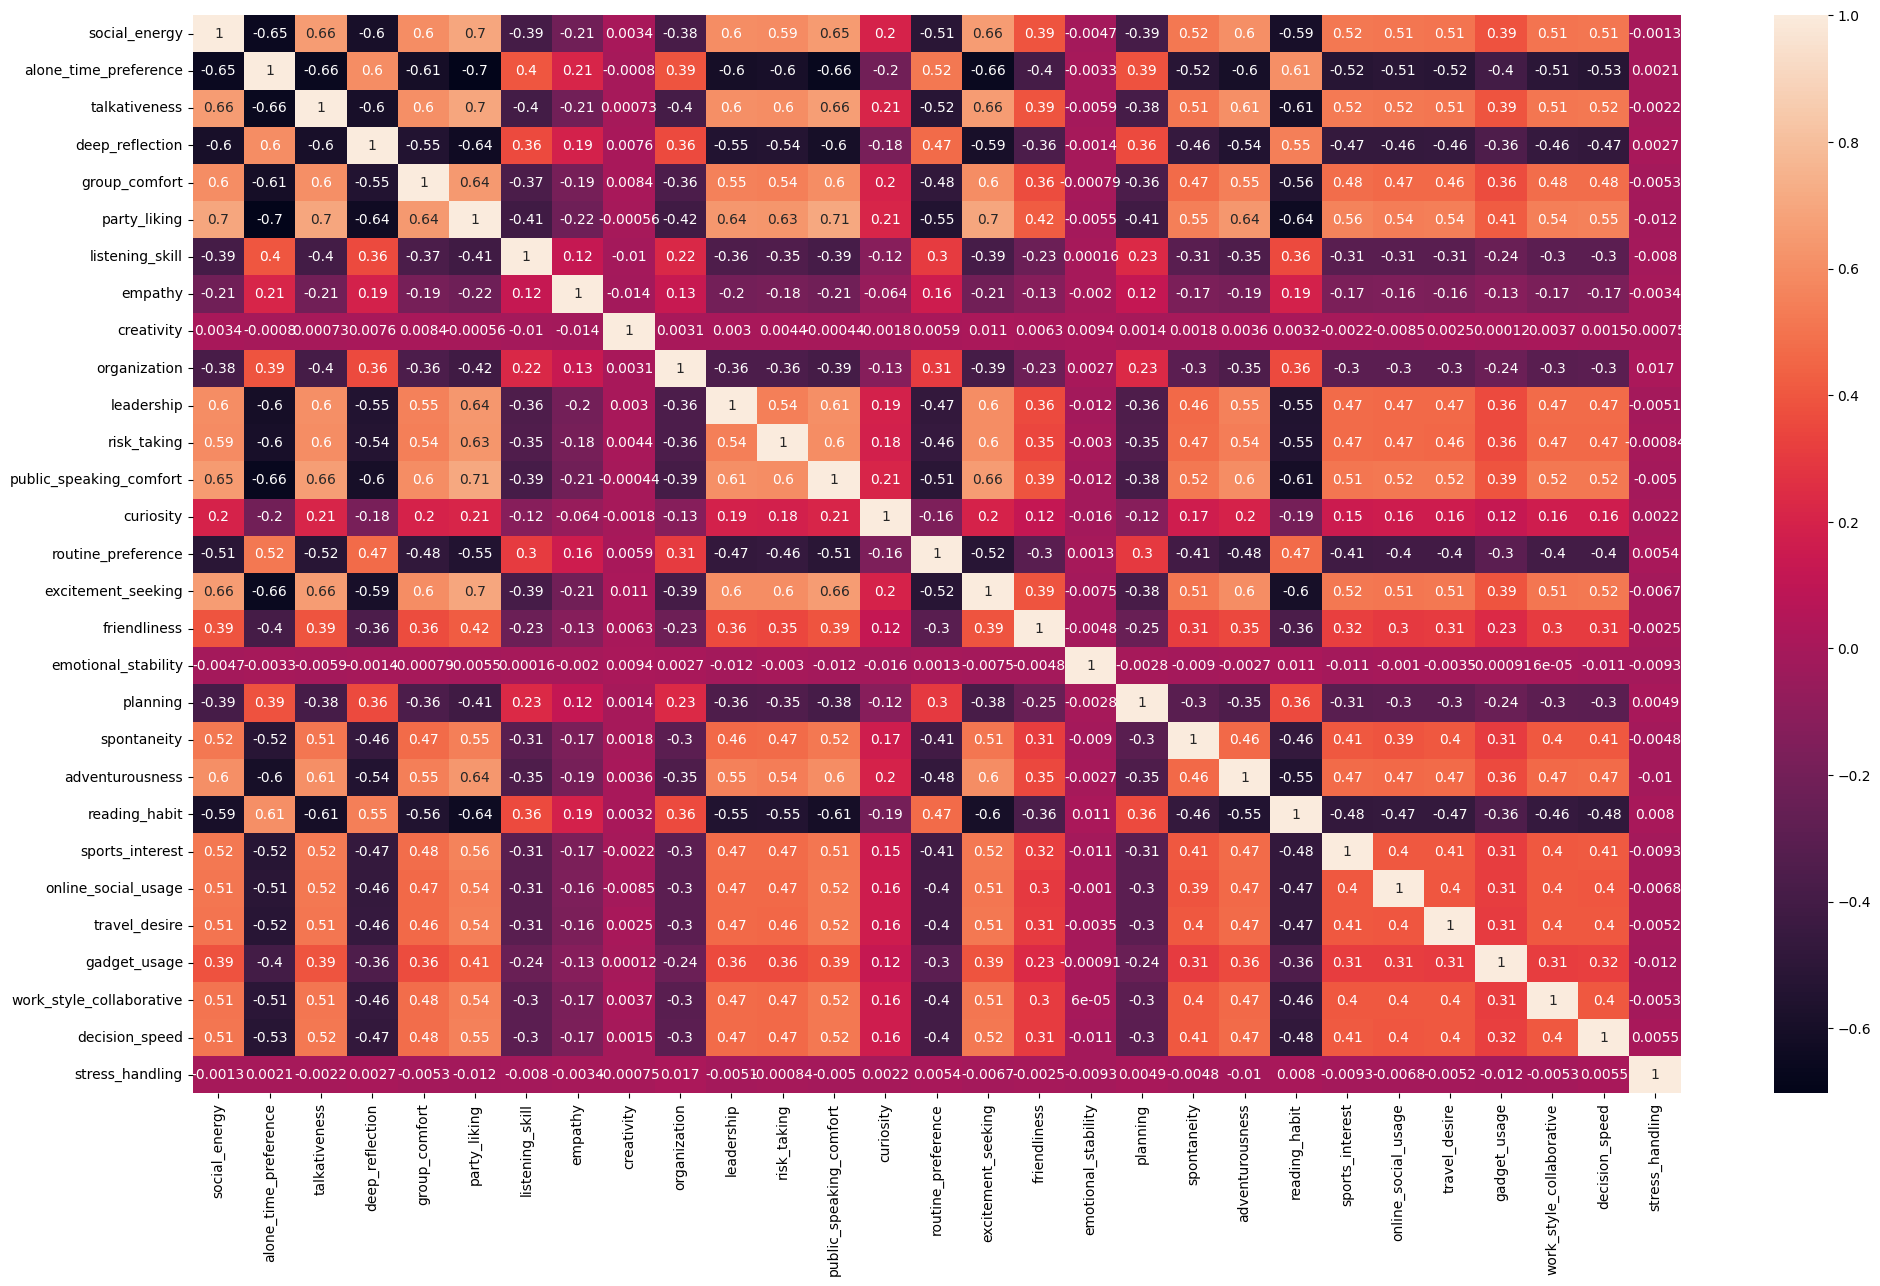

In [14]:
plt.figure(figsize=(24,14))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [16]:
# Label encoding personality column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['personality_type'] = le.fit_transform(df['personality_type'])

In [18]:
# Saperating X and y
X = df.drop('personality_type',axis=1)
y = df['personality_type']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.activations import relu, softmax

In [23]:
model = Sequential()

# Input Layer
model.add(Dense(units=32, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer (MULTI-CLASS)
model.add(Dense(units=3, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [25]:
early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


In [27]:
model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.3,
    callbacks=[early]
)


Epoch 1/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9965 - loss: 0.0112 - val_accuracy: 0.9967 - val_loss: 0.0122
Epoch 2/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 0.9967 - val_loss: 0.0106
Epoch 3/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9974 - loss: 0.0064 - val_accuracy: 0.9956 - val_loss: 0.0143
Epoch 4/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9967 - loss: 0.0099 - val_accuracy: 0.9960 - val_loss: 0.0102
Epoch 5/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9983 - loss: 0.0065 - val_accuracy: 0.9958 - val_loss: 0.0134
Epoch 6/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9977 - loss: 0.0085 - val_accuracy: 0.9965 - val_loss: 0.0119
Epoch 7/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9984 - loss: 0.0049 - val_accuracy: 0.9956 - val_loss: 0.0173
Epoch 8/100
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accu

In [28]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.016057439148426056
Test Accuracy: 0.996749997138977


In [32]:
from sklearn.metrics import confusion_matrix

y_pred_prob = model.predict(X_test)
y_pred = tf.argmax(y_pred_prob, axis=1)
confusion_matrix(y_test, y_pred)


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[1255,    3,    3],
       [   4, 1422,    0],
       [   3,    0, 1310]])

In [33]:
y_pred_prob = model.predict(X_test)
y_pred = tf.argmax(y_pred_prob, axis=1)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.99675
[[1255    3    3]
 [   4 1422    0]
 [   3    0 1310]]
              precision    recall  f1-score   support

    Ambivert       0.99      1.00      0.99      1261
   Extrovert       1.00      1.00      1.00      1426
   Introvert       1.00      1.00      1.00      1313

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [34]:
model.save("personality_ann_model.h5")


In [35]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(sc, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
